# Clinical NLP Pipeline — End-to-End Demo

**Predicting 30-Day Hospital Readmission from Discharge Summaries**

This notebook runs the full pipeline:
1. **Data Generation & Loading** — Synthetic MIMIC-IV-style clinical data
2. **Preprocessing** — Clinical text cleaning, tokenization, phrase detection
3. **Topic Modeling** — LDA topic discovery on discharge notes
4. **Feature Engineering** — TF-IDF, topic distributions, structured features, text statistics
5. **Prediction** — Logistic Regression, Random Forest, XGBoost, LightGBM
6. **Fairness Audit** — Disparity analysis across gender, insurance, age group
7. **Visualization** — Publication-quality figures

In [1]:
import sys, os, logging, warnings
from pathlib import Path

# Project root setup
PROJECT_ROOT = Path(os.getcwd()).parent if "notebooks" in os.getcwd() else Path(os.getcwd())
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

# Logging & warnings
logging.basicConfig(level=logging.INFO, format="%(asctime)s — %(levelname)s — %(message)s")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import yaml
import numpy as np
import pandas as pd

with open("config/config.yaml") as f:
    config = yaml.safe_load(f)

print(f"Project root: {PROJECT_ROOT}")
print("Config loaded successfully.")

2026-04-09 21:59:31,826 — INFO — NumExpr defaulting to 8 threads.


Project root: C:\Users\USER\Desktop\AkashGroup\ClinicalNLP
Config loaded successfully.


## 1. Data Generation & Loading

Generate synthetic clinical data (patients, admissions, discharge notes) mimicking the MIMIC-IV schema, then load and merge into a single analysis-ready DataFrame.

In [2]:
from src.generate_synthetic_data import run as generate_data
from src.data_loader import load_all, get_data_summary

# Generate synthetic data (200 patients -> ~300+ notes)
generate_data(output_dir="data", n_patients=200)

# Load & merge all tables
df = load_all(config, use_synthetic=True)
summary = get_data_summary(df)

print(f"\nDataset shape: {df.shape}")
df.head(3)

2026-04-09 21:59:32,186 — INFO — Generating 200 synthetic patients...


2026-04-09 21:59:32,191 — INFO — Generating admissions with 18% readmission rate...


2026-04-09 21:59:32,273 — INFO — Admissions generated: 332 rows


2026-04-09 21:59:32,273 — INFO — Generating synthetic discharge notes...


2026-04-09 21:59:32,343 — INFO — Discharge notes generated: 332 rows


...

2026-04-09 21:59:32,446 — INFO — Patients loaded: 200 rows


2026-04-09 21:59:32,447 — INFO — Merging notes + admissions + patients ...


2026-04-09 21:59:32,456 — INFO — Merged dataset shape: (332, 28)


--------------------------------------------------
DATASET SUMMARY
--------------------------------------------------
  Total notes          : 332
  Unique patients      : 200
  Unique admissions    : 332
  Readmission rate     : 15.9%
  Avg note length      : 420 words

  Gender distribution  : {'M': 180, 'F': 152}
  Age (mean/median)    : 64.3 / 70.0 yrs  [19–89]
  Age groups           : {'65+': 201, '40-65': 95, '<40': 36}
  Insurance types      : {'Medicare': 141, 'Other': 110, 'Medicaid': 81}
--------------------------------------------------

Dataset shape: (332, 28)


,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,text,admittime,dischtime,...,edouttime,hospital_expire_flag,readmission_30day,gender,anchor_age,anchor_year,anchor_year_group,dod,los_days,age_group
0,30000000,10000000,20000000,Discharge summary,1,2111-10-12 15:56:19,2111-10-12 15:56:19,Admission Date: ___\nDischarge Date: ___\nDate...,2111-10-06 15:56:19,2111-10-12 15:56:19,...,2111-10-06 15:56:19,0,0,M,75,2108,2106-2108,NaN,6.0,65+
1,30000001,10000000,20000001,Discharge summary,1,2112-09-22 15:56:19,2112-09-22 15:56:19,Admission Date: ___\nDischarge Date: ___\nDate...,2112-09-16 15:56:19,2112-09-22 15:56:19,...,2112-09-16 15:56:19,0,1,M,75,2108,2106-2108,NaN,6.0,65+
2,30000002,10000000,20000002,Discharge summary,1,2112-10-17 15:56:19,2112-10-17 15:56:19,Admission Date: ___\nDischarge Date: ___\nDate...,2112-10-10 15:56:19,2112-10-17 15:56:19,...,2112-10-10 15:56:19,0,-1,M,75,2108,2106-2108,NaN,7.0,65+


## 2. Preprocessing

Clean clinical text (remove PHI patterns, dates, special characters), tokenize with NLTK, and prepare documents for topic modeling and feature extraction.

In [3]:
from src.preprocess import build_preprocessing_pipeline

processed = build_preprocessing_pipeline(df, config=config, use_scispacy=False, use_phrases=False)

print(f"Processed shape: {processed.shape}")
print(f"Avg tokens per note: {processed['num_tokens'].mean():.1f}")
print(f"\nSample cleaned text (first 200 chars):")
print(processed["cleaned_text"].iloc[0][:200])
print(f"\nSample tokens: {processed['tokens'].iloc[0][:15]}")

2026-04-09 21:59:32,511 — INFO — Step 1/4 — removing unwanted sections from 332 notes ...


2026-04-09 21:59:32,570 — INFO — Step 2/4 — cleaning text ...


2026-04-09 21:59:32,709 — INFO — Filtered 0 notes outside length bounds — 332 remaining


2026-04-09 21:59:32,709 — INFO — Step 3/4 — tokenizing 332 notes (use_scispacy=False) ...


2026-04-09 21:59:34,523 — INFO — Downloading NLTK resource: wordnet


2026-04-09 21:59:34,828 — INFO — Downloading NLTK resource: averaged_perceptron_tagger


2026-04-09 21:59:41,097 — INFO — Loaded spacy model: en_core_web_sm (parser/ner disabled)


2026-04-09 21:59:55,539 — INFO — Step 4/4 — skipping phrase detection.


2026-04-09 21:59:55,545 — INFO — Preprocessing complete — vocab size: 809, avg tokens/doc: 197.3


Processed shape: (332, 31)
Avg tokens per note: 197.3

Sample cleaned text (first 200 chars):
admission date: 
discharge date: 
date of birth: 
sex: m
service: medicine
allergies: no known allergies
attending: md

chief complaint:
aki

history of present illness:
the patient is a 75-year-old m

Sample tokens: ['birth', 'sex', 'service', 'medicine', 'allergy', 'know', 'allergy', 'attend', 'md', 'chief', 'complaint', 'aki', 'present', 'illness', 'male']


## 2.5 Clinical Embeddings (ClinicalBERT)

Generate dense 768-dimensional embeddings from discharge notes using [Bio_ClinicalBERT](https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT), a BERT model pre-trained on clinical text from MIMIC-III. Long notes are handled via sliding-window chunking with mean pooling. Optionally reduced to 50 dims via PCA for use with classical ML models.

In [4]:
from src.embeddings import embed_texts

# Use cleaned text for embeddings (preserves more semantic content than tokens)
emb_cfg = config.get("embeddings", {})
texts_for_embedding = processed["cleaned_text"].tolist()

print(f"Generating clinical embeddings for {len(texts_for_embedding)} notes ...")
print(f"  Model: {emb_cfg.get('model_name', 'clinicalbert')}")
print(f"  Pooling: {emb_cfg.get('pooling', 'mean')}")
print(f"  Device: {emb_cfg.get('device', 'auto-detect')}")

embedding_matrix, emb_metadata = embed_texts(
    texts_for_embedding,
    model_name=emb_cfg.get("model_name", "clinicalbert"),
    pooling=emb_cfg.get("pooling", "mean"),
    max_length=emb_cfg.get("max_length", 512),
    stride=emb_cfg.get("stride", 256),
    device=emb_cfg.get("device", None),
)

print(f"\nEmbedding matrix shape: {embedding_matrix.shape}")
print(f"  Hidden size: {emb_metadata['hidden_size']}")
print(f"  Chunked documents: {emb_metadata['n_chunked']}/{emb_metadata['n_documents']}")
print(f"  Device used: {emb_metadata['device']}")

2026-04-09 22:00:00,739 — INFO — Loading embedding model: clinicalbert → emilyalsentzer/Bio_ClinicalBERT (device=cpu)


Generating clinical embeddings for 332 notes ...
  Model: clinicalbert
  Pooling: mean
  Device: None


2026-04-09 22:00:01,266 — INFO — HTTP Request: HEAD https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"


2026-04-09 22:00:01,316 — INFO — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/emilyalsentzer/Bio_ClinicalBERT/d5892b39a4adaed74b92212a44081509db72f87b/config.json "HTTP/1.1 200 OK"


2026-04-09 22:00:01,632 — INFO — HTTP Request: HEAD https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT/resolve/main/tokenizer_config.json "HTTP/1.1 404 Not Found"


...

Embedding texts: 100%|█████████▉| 331/332 [08:23<00:01,  1.43s/it]

Embedding texts: 100%|██████████| 332/332 [08:24<00:00,  1.41s/it]

Embedding texts: 100%|██████████| 332/332 [08:24<00:00,  1.52s/it]


2026-04-09 22:08:29,198 — INFO — Embeddings complete — shape: (332, 768), chunked: 330/332 docs, device: cpu



Embedding matrix shape: (332, 768)
  Hidden size: 768
  Chunked documents: 330/332
  Device used: cpu


## 3. Topic Modeling (LDA)

Discover latent clinical topics in discharge notes using Latent Dirichlet Allocation. We grid-search over topic counts and select the best by coherence score.

In [5]:
from src.topic_model import run_lda_pipeline

# Filter to eligible notes (readmission label >= 0)
eligible_mask = processed["readmission_30day"] >= 0
eligible_df = processed[eligible_mask].reset_index(drop=True)
tokenized_docs = eligible_df["tokens"].apply(lambda t: t if isinstance(t, list) else []).tolist()

print(f"Eligible documents for topic modeling: {len(tokenized_docs)}")

# Run LDA pipeline (grid search over num_topics)
lda_results = run_lda_pipeline(tokenized_docs, config=config)

print(f"\nBest number of topics: {lda_results['best_num_topics']}")
print(f"Coherence scores: {lda_results['coherence_scores']}")
print(f"\nTopic labels:")
for tid, label in lda_results["topic_labels"].items():
    words = ", ".join(w for w, _ in lda_results["topic_words"][tid][:6])
    print(f"  Topic {tid:2d} [{label}]: {words} ...")

Eligible documents for topic modeling: 132


2026-04-09 22:08:29,428 — INFO — Building dictionary and corpus ...


2026-04-09 22:08:29,429 — INFO — adding document #0 to Dictionary<0 unique tokens: []>


2026-04-09 22:08:29,455 — INFO — built Dictionary<609 unique tokens: ['108/103', 'aaox3', 'acquire', 'activity', 'acute']...> from 132 documents (total 26086 corpus positions)


2026-04-09 22:08:29,456 — INFO — Dictionary lifecycle event {'msg': "built Dictionary<609 unique tokens: ['108/103', 'aaox3', 'acquire', 'activity', 'acute']...> from 132 documents (total 26086 corpus positions)", 'datetime': '2026-04-09T22:08:29.456061', 'gensim': '4.4.0', 'python': '3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'created'}


...

2026-04-09 22:08:58,351 — INFO —   Topic 11 [Infection / Sepsis (2)]: sepsis, iv, male, disease, vasopressor, culture ...


2026-04-09 22:08:58,351 — INFO —   Topic 12 [Renal / Kidney (2)]: male, pain, iv, chest, use, kidney ...


2026-04-09 22:08:58,353 — INFO —   Topic 13 [Respiratory / Pulmonary (2)]: pulmonary, female, twice, embolism, bilateral, gerd ...


2026-04-09 22:08:58,356 — INFO —   Topic 14 [Respiratory / Pulmonary (3)]: female, levofloxacin, x7, disease, nightly, dvt ...



Best number of topics: 15
Coherence scores: {5: np.float64(0.2764), 10: np.float64(0.4619), 15: np.float64(0.4847), 20: np.float64(0.4369)}

Topic labels:
  Topic  0 [Neurological]: stroke, therapy, initiate, acute, neurology, female ...
  Topic  1 [Neurological (2)]: mental, status, male, altered, non, alter ...
  Topic  2 [Respiratory / Pulmonary]: copd, male, disease, prednisone, iv, pulmonary ...
  Topic  3 [Neurological (3)]: stroke, male, therapy, initiate, hypertension, apnea ...
  Topic  4 [Endocrine / Metabolic]: insulin, dka, subcutaneous, glucose, diabetic, ketoacidosis ...
  Topic  5 [Cardiovascular]: female, iv, gi, disease, extremity, edema ...
  Topic  6 [Cardiovascular (2)]: ejection, fraction, reduced, heart, failure, non ...
  Topic  7 [Cardiovascular (3)]: type, mellitus, general, alert, distress, orient ...
  Topic  8 [Infection / Sepsis]: pneumonia, culture, female, acquire, antibiotic, use ...
  Topic  9 [Renal / Kidney]: aki, kidney, injury, fluid, acute, nephro

In [6]:
# Topic summary table
lda_results["topics_df"]

,topic_id,label,top_words,top_word_weights
0,0,Neurological,"stroke, therapy, initiate, acute, neurology, f...","[0.0536, 0.0379, 0.0242, 0.0161, 0.016, 0.0159..."
1,1,Neurological (2),"mental, status, male, altered, non, alter, str...","[0.0487, 0.0487, 0.044, 0.0326, 0.0267, 0.0164..."
2,2,Respiratory / Pulmonary,"copd, male, disease, prednisone, iv, pulmonary...","[0.0411, 0.0181, 0.0162, 0.0156, 0.0154, 0.014..."
3,3,Neurological (3),"stroke, male, therapy, initiate, hypertension,...","[0.0288, 0.0248, 0.0247, 0.0219, 0.0207, 0.016..."
4,4,Endocrine / Metabolic,"insulin, dka, subcutaneous, glucose, diabetic,...","[0.047, 0.039, 0.0157, 0.0157, 0.0157, 0.0157,..."
5,5,Cardiovascular,"female, iv, gi, disease, extremity, edema, art...","[0.0267, 0.0209, 0.0197, 0.0186, 0.0143, 0.014..."
6,6,Cardiovascular (2),"ejection, fraction, reduced, heart, failure, n...","[0.0344, 0.0344, 0.0343, 0.0315, 0.0315, 0.026..."
7,7,Cardiovascular (3),"type, mellitus, general, alert, distress, orie...","[0.0423, 0.0423, 0.0334, 0.0287, 0.0284, 0.028..."
8,8,Infection / Sepsis,"pneumonia, culture, female, acquire, antibioti...","[0.0302, 0.0202, 0.0148, 0.0139, 0.0136, 0.013..."
9,9,Renal / Kidney,"aki, kidney, injury, fluid, acute, nephrology,...","[0.0728, 0.0704, 0.0435, 0.0387, 0.038, 0.0291..."


## 3.5 BERTopic (Transformer-Based Topic Modeling)

Discover topics using [BERTopic](https://maartengr.github.io/BERTopic/) with BioBERT embeddings, UMAP dimensionality reduction, and HDBSCAN clustering. This provides a complementary view to LDA.

In [ ]:
from src.topic_model import train_bertopic, compare_models

# BERTopic needs raw cleaned text strings (not tokenized)
cleaned_texts = eligible_df["cleaned_text"].tolist()

print(f"Fitting BERTopic on {len(cleaned_texts)} documents ...")
bertopic_model, bt_topics, bt_probs = train_bertopic(cleaned_texts, config=config)

if bertopic_model is not None:
    topic_info = bertopic_model.get_topic_info()
    n_topics = len(topic_info[topic_info["Topic"] != -1])
    n_outliers = (bt_topics.count(-1)) if isinstance(bt_topics, list) else int((np.array(bt_topics) == -1).sum())
    print(f"BERTopic found {n_topics} topics ({n_outliers} outlier docs)")
    print(f"
Top 5 topics:")
    display(topic_info.head(6))
else:
    print("BERTopic not available (missing dependencies).")

### LDA vs BERTopic Comparison & Topic-Readmission Association

Compare the two topic models on coherence and diversity, then test whether any topics are statistically associated with 30-day readmission using the Mann-Whitney U test.

In [ ]:
from src.topic_model import compare_models, test_topic_readmission_association

# --- Model comparison ---
comparison_df = compare_models(
    lda_topic_words=lda_results["topic_words"],
    bertopic_model=bertopic_model,
    texts=tokenized_docs,
    dictionary=lda_results["dictionary"],
    corpus=lda_results["corpus"],
)
print("Model Comparison:")
display(comparison_df)

# --- Topic-Readmission statistical test (LDA) ---
readmission_labels = eligible_df["readmission_30day"].values.astype(int)
doc_topic_matrix = lda_results["doc_topic_matrix"]

assoc_df = test_topic_readmission_association(
    doc_topic_matrix=doc_topic_matrix,
    readmission_labels=readmission_labels,
    topic_labels=lda_results["topic_labels"],
)

print(f"
Topic-Readmission Association (Mann-Whitney U test):")
print(f"Significant topics (p < 0.05): {assoc_df["significant"].sum()} / {len(assoc_df)}")
display(assoc_df)

## 4. Feature Engineering

Build multiple feature representations:
- **TF-IDF** — Bag-of-words text representation
- **Topic distributions** — LDA document-topic probabilities
- **Structured** — Demographics, admission info, prior utilization
- **Text statistics** — Note length, negations, section count
- **Combined** — All of the above stacked

In [ ]:
from src.feature_engineer import build_feature_sets

feature_sets = build_feature_sets(
    processed,
    lda_results=lda_results,
    bertopic_model=bertopic_model if "bertopic_model" in dir() and bertopic_model is not None else None,
    config=config,
    embedding_matrix=embedding_matrix,
)

print("Feature sets built:")
for key in ["tfidf", "topic_lda", "topic_bertopic", "embeddings", "structured", "text_stats", "combined"]:
    entry = feature_sets.get(key)
    if entry and entry.get("X") is not None:
        shape = entry["X"].shape
        print(f"  {key:20s} -- shape: {shape}")
    elif entry is None:
        print(f"  {key:20s} -- skipped")

print(f"
Labels: {len(feature_sets["label"])} samples")
print(f"  Readmitted: {feature_sets["label"].sum()} ({feature_sets["label"].mean()*100:.1f}%)")

## 5. Prediction Pipeline

Train Logistic Regression, Random Forest, XGBoost, and LightGBM on each feature set. Evaluate with ROC-AUC, F1, PR-AUC, and cross-validation.

In [8]:
from src.predict import run_prediction_pipeline

prediction_results = run_prediction_pipeline(feature_sets, config=config)

# Summary table
display_cols = ["model", "feature_type", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
results_df = prediction_results["results_df"]
results_df[display_cols].sort_values("roc_auc", ascending=False)

2026-04-09 22:08:58,714 — INFO — ============================================================


2026-04-09 22:08:58,715 — INFO — Feature set: tfidf — shape (132, 1223)


2026-04-09 22:08:58,716 — INFO — ============================================================


2026-04-09 22:08:58,722 — INFO — Split — train: 91, val: 14, test: 27  (pos rate: train=16.5%, val=14.3%, test=14.8%)


2026-04-09 22:08:58,723 — INFO — --- logistic_regression + tfidf ---


...

2026-04-09 22:09:06,439 — INFO — Saved model: results\models\random_forest__combined.joblib


2026-04-09 22:09:06,439 — INFO — Saved model: results\models\xgboost__combined.joblib


2026-04-09 22:09:06,455 — INFO — Saved model: results\models\lightgbm__combined.joblib


2026-04-09 22:09:06,455 — INFO — Saved 20 models to results\models


,model,feature_type,accuracy,precision,recall,f1,roc_auc,pr_auc
12,logistic_regression,embeddings,0.8519,0.5000,0.75,0.6000,0.8587,0.5506
0,logistic_regression,tfidf,0.9259,0.7500,0.75,0.7500,0.7826,0.6496
3,lightgbm,tfidf,0.8519,0.0000,0.00,0.0000,0.7826,0.3000
2,xgboost,tfidf,0.8889,0.6667,0.50,0.5714,0.7283,0.6412
16,logistic_regression,combined,0.8519,0.5000,0.50,0.5000,0.7283,0.5455
13,random_forest,embeddings,0.8519,0.0000,0.00,0.0000,0.7283,0.3713
6,xgboost,topic_distribution,0.8148,0.3333,0.25,0.2857,0.7174,0.3417
14,xgboost,embeddings,0.8148,0.0000,0.00,0.0000,0.6957,0.3208
4,logistic_regression,topic_distribution,0.8519,0.5000,0.50,0.5000,0.6957,0.4018
7,lightgbm,topic_distribution,0.7778,0.2500,0.25,0.2500,0.6793,0.4307


In [9]:
# Best model summary
best = prediction_results["best"]
print(f"Best model: {best.get('model')} + {best.get('feature_type')}")
print(f"  ROC-AUC: {best.get('roc_auc', 0):.4f}")
print(f"  F1:      {best.get('f1', 0):.4f}")
print(f"  PR-AUC:  {best.get('pr_auc', 0):.4f}")

# Cross-validation results
if prediction_results["cv_results"]:
    print("\nCross-validation results:")
    for cv in prediction_results["cv_results"]:
        print(f"  {cv['model']} + {cv['feature_type']} — "
              f"F1: {cv['f1_mean']:.3f}±{cv['f1_std']:.3f} | "
              f"ROC-AUC: {cv['roc_auc_mean']:.3f}±{cv['roc_auc_std']:.3f}")

Best model: logistic_regression + embeddings
  ROC-AUC: 0.8587
  F1:      0.6000
  PR-AUC:  0.5506

Cross-validation results:
  logistic_regression + tfidf — F1: 0.368±0.145 | ROC-AUC: 0.691±0.159
  xgboost + topic_distribution — F1: 0.267±0.170 | ROC-AUC: 0.518±0.143
  logistic_regression + structured — F1: 0.261±0.060 | ROC-AUC: 0.473±0.129
  logistic_regression + embeddings — F1: 0.350±0.224 | ROC-AUC: 0.683±0.170
  logistic_regression + combined — F1: 0.194±0.198 | ROC-AUC: 0.510±0.193


## 6. Fairness Audit

Evaluate prediction fairness across protected attributes (gender, insurance, age group) using Fairlearn. We check for demographic parity, equalized odds, and false positive/negative rate disparities.

In [10]:
from src.fairness import run_fairness_audit

# Use the best model's predictions for the fairness audit
best_model_name = best.get("model", "logistic_regression")
best_feat_type = best.get("feature_type", "structured")
best_model = prediction_results["models"].get((best_model_name, best_feat_type))
best_splits = prediction_results["splits"].get(best_feat_type)

if best_model and best_splits:
    y_test = best_splits["y_test"]
    X_test = best_splits["X_test"]
    y_prob = best_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    # Get the eligible DataFrame aligned with the test split
    eligible_df = feature_sets["eligible_df"]

    # Reconstruct test indices via the split
    from src.predict import split_data
    test_size = config.get("prediction", {}).get("test_size", 0.2)
    val_size = config.get("prediction", {}).get("val_size", 0.1)
    feat_entry = feature_sets.get(
        {"tfidf": "tfidf", "topic_distribution": "topic_lda",
         "structured": "structured", "combined": "combined"}.get(best_feat_type, best_feat_type)
    )
    X_full = feat_entry["X"]
    labels = feature_sets["label"]

    from sklearn.model_selection import train_test_split
    _, X_test_idx, _, _ = train_test_split(
        np.arange(len(labels)), labels,
        test_size=test_size, stratify=labels, random_state=42,
    )

    # Build protected attributes DataFrame for test set
    protected_cols = config.get("fairness", {}).get("protected_attributes", ["gender", "insurance", "age_group"])
    protected_df = eligible_df.loc[X_test_idx, protected_cols].reset_index(drop=True)

    fairness_results = run_fairness_audit(
        y_true=y_test,
        y_pred=y_pred,
        y_prob=y_prob,
        protected_df=protected_df,
        config=config,
    )
else:
    print("Best model not available for fairness audit.")

2026-04-09 22:09:06,763 — INFO — Group metrics for 'gender':
        n_samples  positive_rate  accuracy  precision  recall   f1     fpr  fnr
gender                                                                         
F              15         0.1333    0.9333     0.6667     1.0  0.8  0.0769  0.0
M              12         0.1667    0.7500     0.3333     0.5  0.4  0.2000  0.5


2026-04-09 22:09:06,817 — INFO — Fairness [gender] — DPD: 0.0500 | EOD: 0.5000 | FPR diff: 0.1231 | FNR diff: 0.5000


2026-04-09 22:09:06,903 — INFO — Group metrics for 'insurance':
           n_samples  positive_rate  accuracy  precision  recall      f1     fpr     fnr
insurance                                                                               
Medicaid           7         0.0000    0.7143        0.0  0.0000  0.0000  0.2857  0.0000
Medicare           9         0.3333    0.8889        1.0  0.6667  0.8000  0.0000  0.3333
Other             11         0.0909    0.9091        0.5  1.0000  0.6667  0.1000  0.0000


2026-04-09 22:09:06,972 — INFO — Fairness [insurance] — DPD: 0.1039 | EOD: 1.0000 | FPR diff: 0.2857 | FNR diff: 0.3333


2026-04-09 22:09:07,054 — INFO — Group metrics for 'age_group':
           n_samples  positive_rate  accuracy  precision  recall    f1     fpr   fnr
age_group                                                                           
40-65              5         0.0000    0.6000       0.00    0.00  0.00  0.4000  0.00
65+               19         0.2105    0.8947       0.75    0.75  0.75  0.0667  0.25
<40                3         0.0000    1.0000       0.00    0.00  0.00  0.0000  0.00


2026-04-09 22:09:07,141 — INFO — Fairness [age_group] — DPD: 0.4000 | EOD: 0.7500 | FPR diff: 0.4000 | FNR diff: 0.2500



FAIRNESS AUDIT REPORT

--- GENDER ---
        n_samples  positive_rate  accuracy  precision  recall   f1     fpr  fnr
gender                                                                         
F              15         0.1333    0.9333     0.6667     1.0  0.8  0.0769  0.0
M              12         0.1667    0.7500     0.3333     0.5  0.4  0.2000  0.5

--- INSURANCE ---
           n_samples  positive_rate  accuracy  precision  recall      f1     fpr     fnr
insurance                                                                               
Medicaid           7         0.0000    0.7143        0.0  0.0000  0.0000  0.2857  0.0000
Medicare           9         0.3333    0.8889        1.0  0.6667  0.8000  0.0000  0.3333
Other             11         0.0909    0.9091        0.5  1.0000  0.6667  0.1000  0.0000

--- AGE_GROUP ---
           n_samples  positive_rate  accuracy  precision  recall    f1     fpr   fnr
age_group                                                                

In [11]:
# Fairness summary
if fairness_results:
    fairness_results["summary_df"]

## 7. Visualization

Generate all publication-quality figures and save to `results/figures/`.

In [12]:
from src.visualize import generate_all_figures

# Add readmission labels to lda_results for the heatmap
lda_results["readmission_labels"] = feature_sets["label"]

saved_figures = generate_all_figures(
    merged_df=df,
    prediction_results=prediction_results,
    lda_results=lda_results,
    fairness_results=fairness_results if "fairness_results" in dir() else None,
    config=config,
)

print(f"\nGenerated {len(saved_figures)} figures:")
for fig_path in saved_figures:
    print(f"  {fig_path}")

2026-04-09 22:09:08,715 — INFO — Generating dataset distribution plots ...


2026-04-09 22:09:09,934 — INFO — Saved figure: results\figures\demographics.png


2026-04-09 22:09:10,601 — INFO — Saved figure: results\figures\note_length_distribution.png


2026-04-09 22:09:10,602 — INFO — Generating topic modeling plots ...


2026-04-09 22:09:10,873 — INFO — Saved figure: results\figures\coherence_scores.png


...

2026-04-09 22:09:41,112 — INFO — Generating fairness plots ...


2026-04-09 22:09:42,209 — INFO — Saved figure: results\figures\fairness_disparity.png


2026-04-09 22:09:42,889 — INFO — Saved figure: results\figures\fairness_group_metrics.png


2026-04-09 22:09:42,889 — INFO — Generated 12 figures total.



Generated 12 figures:
  results\figures\demographics.png
  results\figures\note_length_distribution.png
  results\figures\coherence_scores.png
  results\figures\topic_word_clouds.png
  results\figures\topic_readmission_heatmap.png
  results\figures\roc_curves.png
  results\figures\pr_curves.png
  results\figures\confusion_matrices.png
  results\figures\model_comparison.png
  results\figures\feature_importance.png
  results\figures\fairness_disparity.png
  results\figures\fairness_group_metrics.png



  Demographics


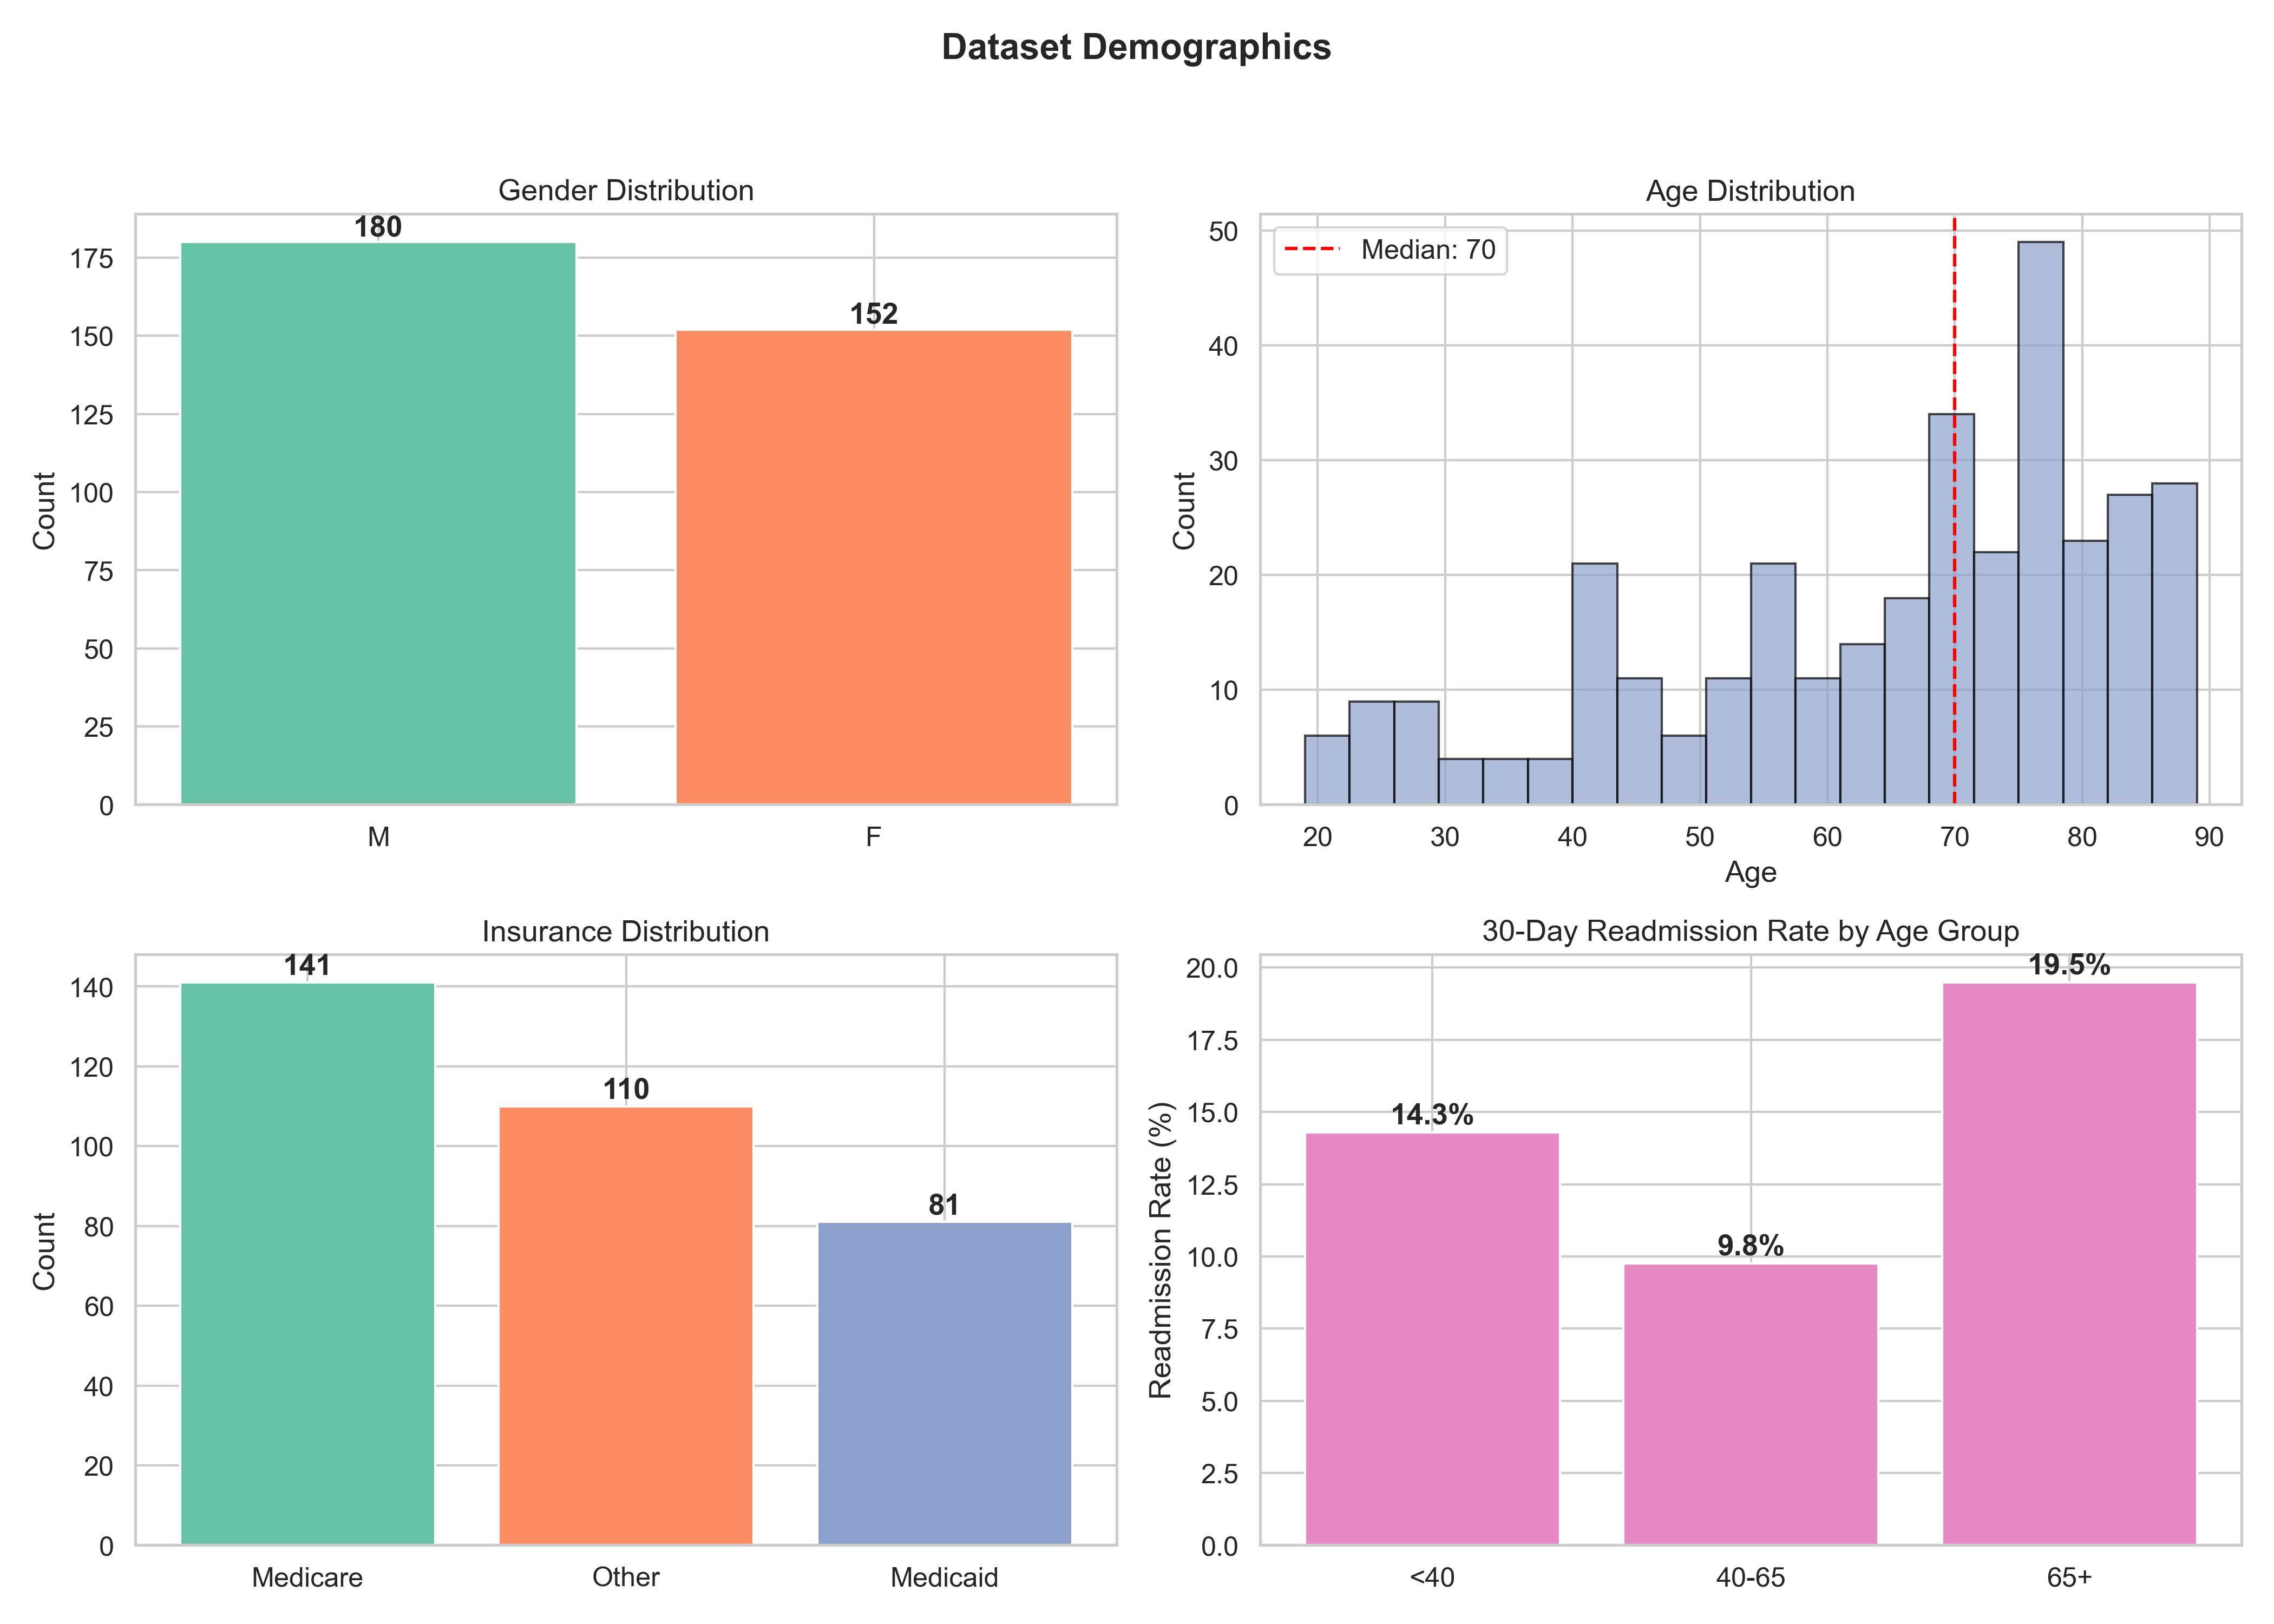


  Roc Curves


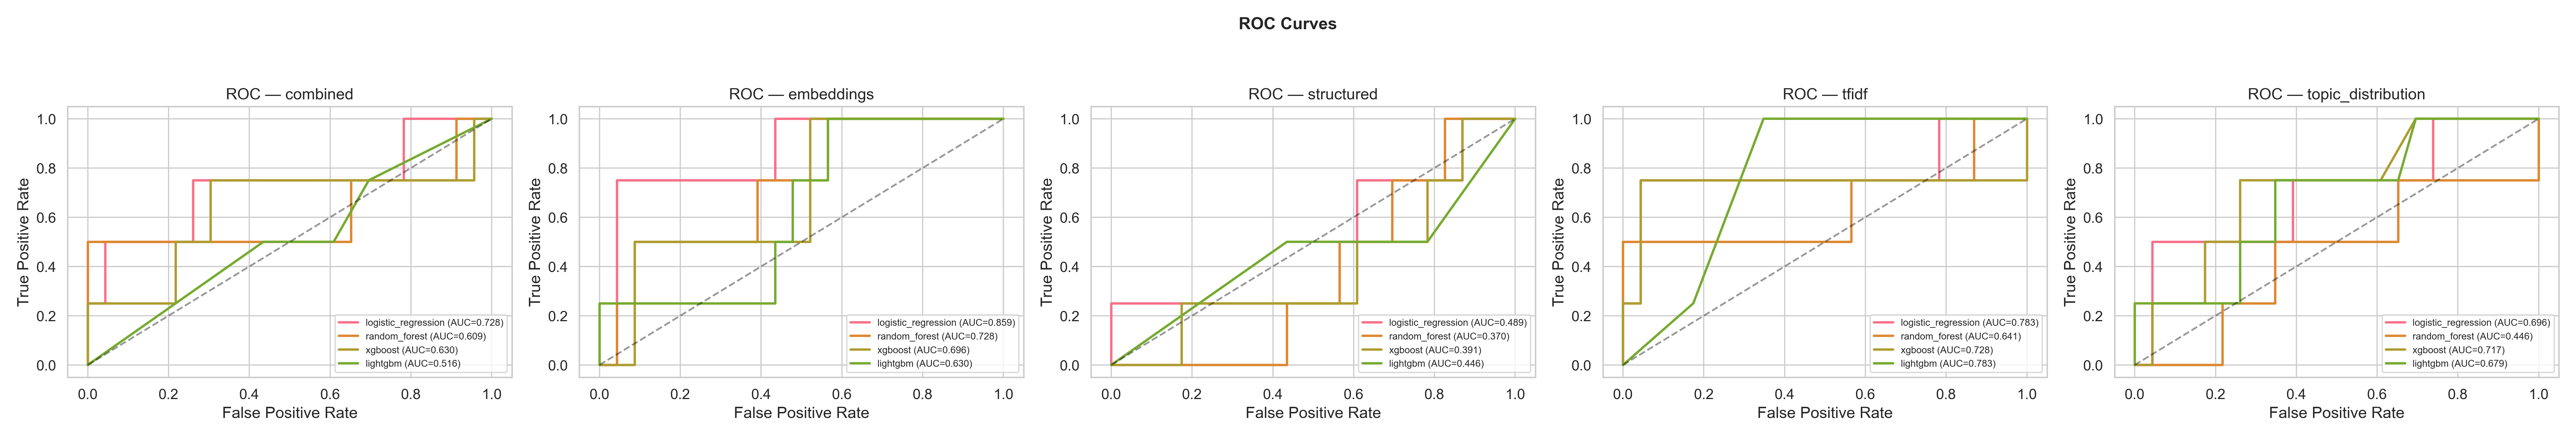


  Model Comparison


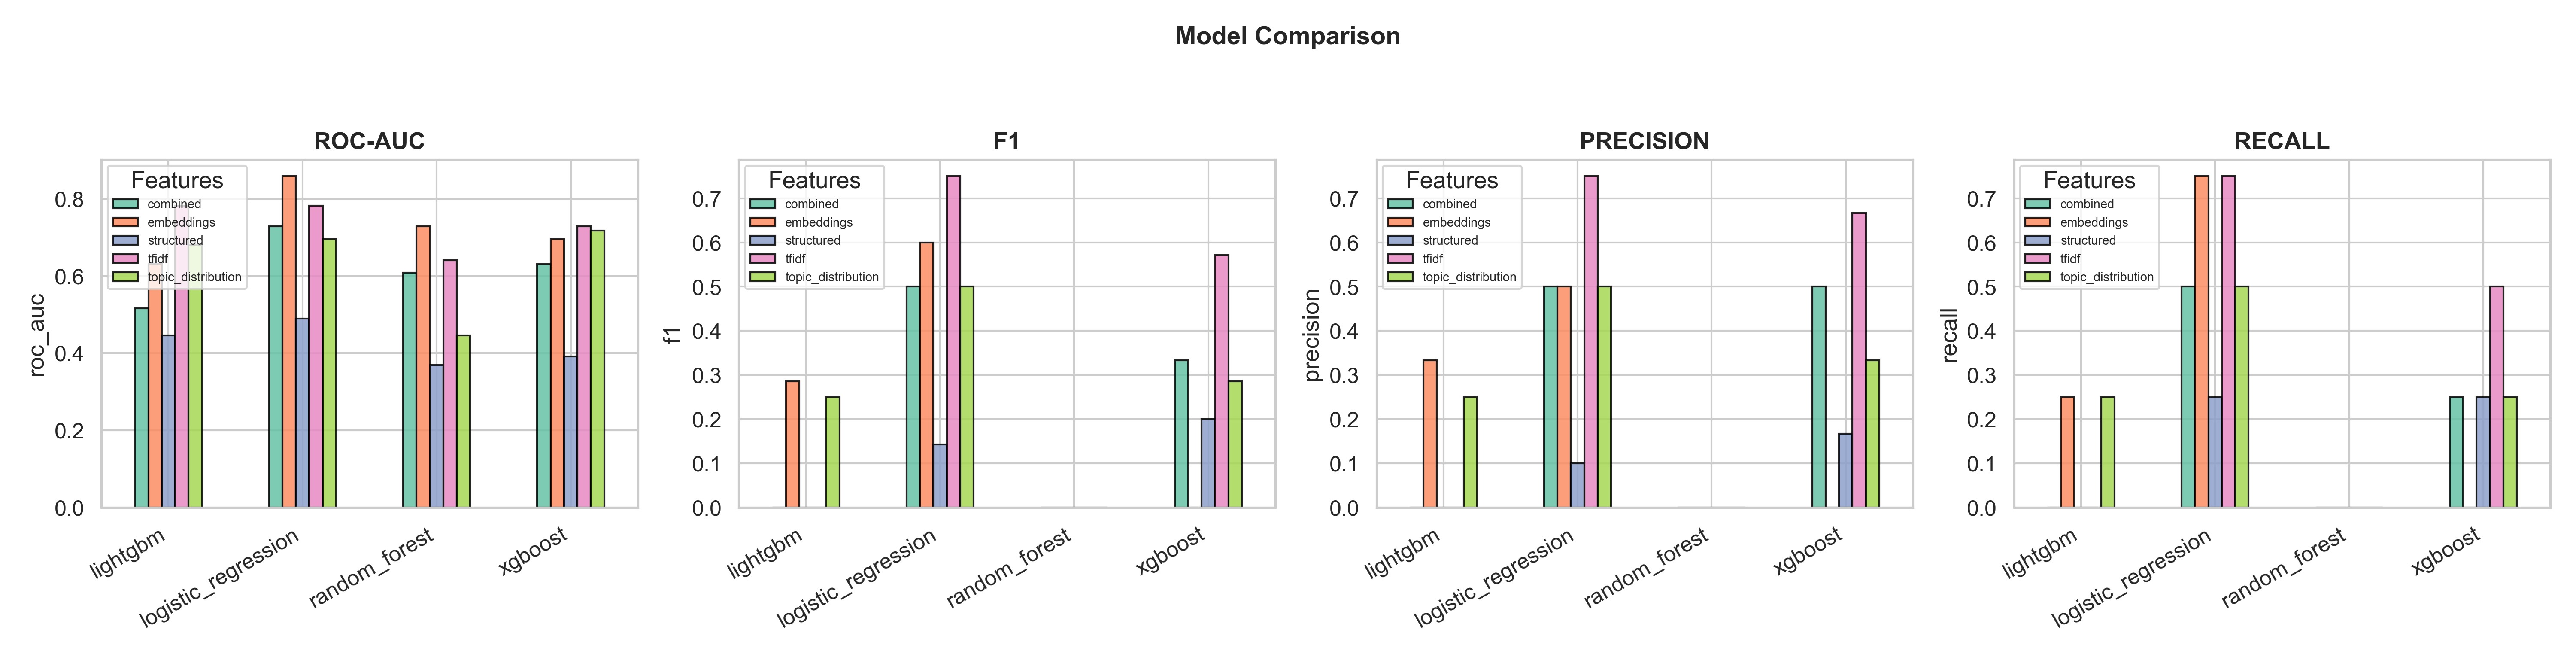


  Fairness Disparity


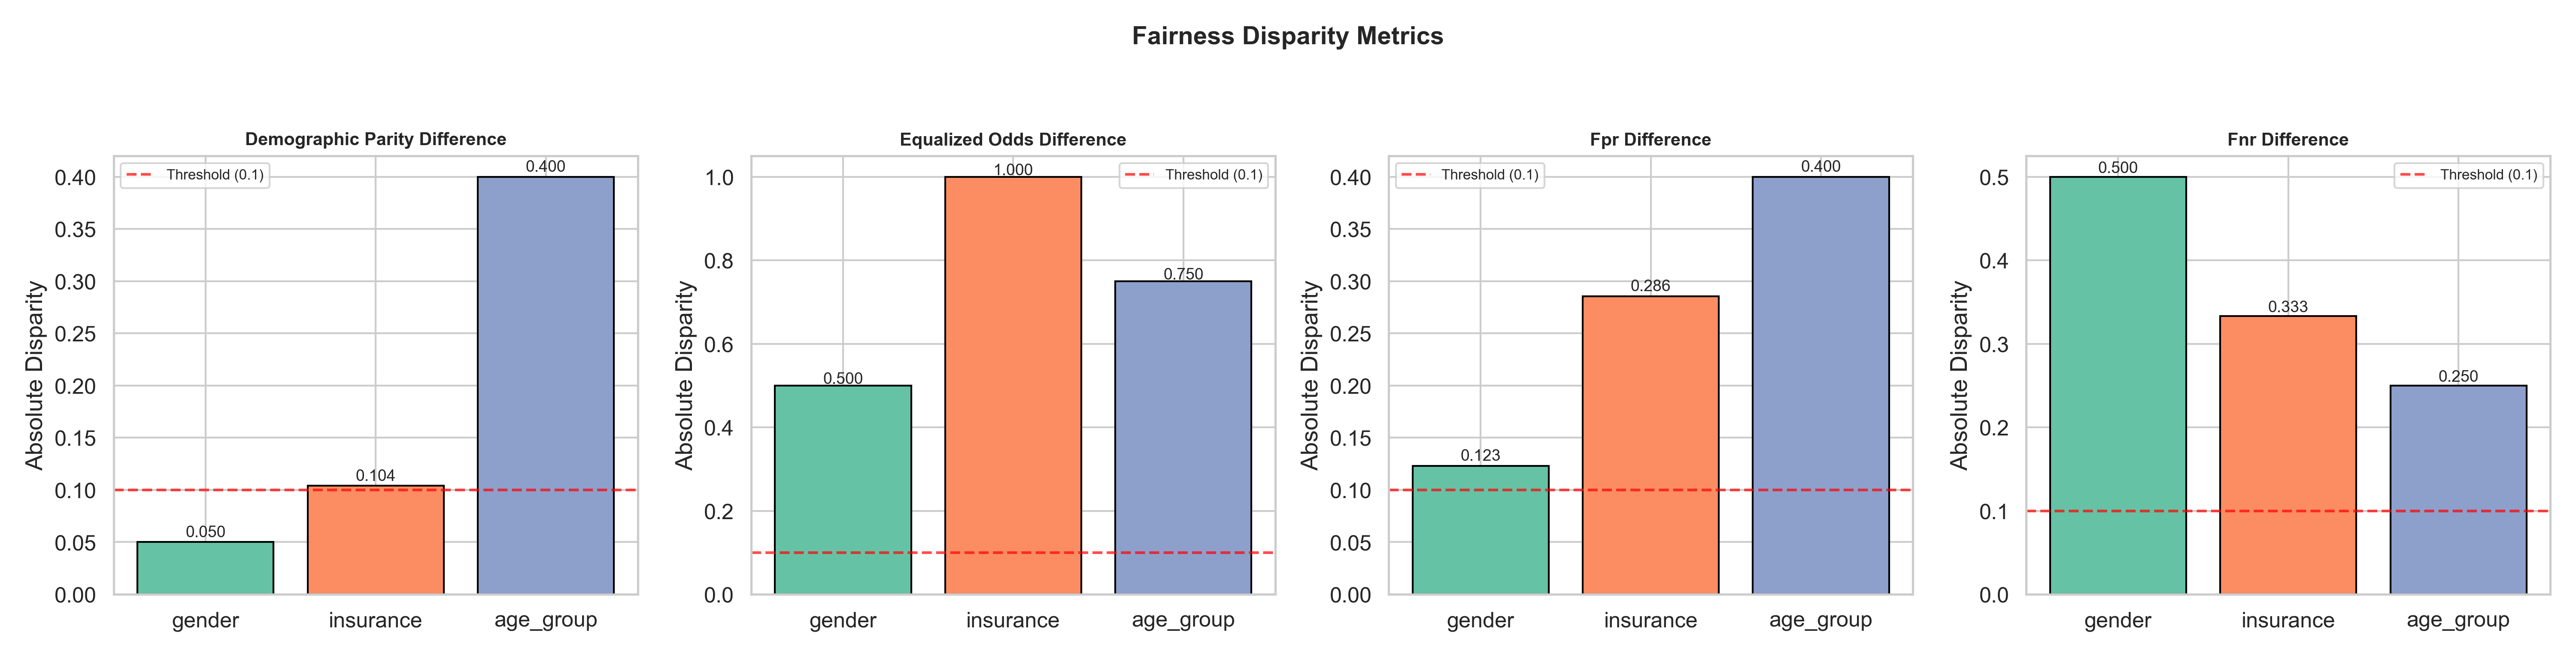

In [13]:
# Display key figures inline
from IPython.display import Image, display

key_figures = ["demographics", "roc_curves", "model_comparison", "fairness_disparity"]
for name in key_figures:
    fig_path = f"results/figures/{name}.png"
    if Path(fig_path).exists():
        print(f"\n{'='*60}")
        print(f"  {name.replace('_', ' ').title()}")
        print(f"{'='*60}")
        display(Image(filename=fig_path, width=800))

## Summary

| Component | Details |
|-----------|---------|
| **Data** | Synthetic MIMIC-IV (200 patients, ~300+ notes) |
| **Preprocessing** | PHI removal, NLTK tokenization, clinical stopwords |
| **Embeddings** | ClinicalBERT (Bio_ClinicalBERT) with sliding-window chunking + PCA reduction |
| **Topic Modeling** | LDA with coherence-based topic selection + BERTopic (BioBERT + UMAP + HDBSCAN) |
| **Topic Analysis** | LDA vs BERTopic comparison, Mann-Whitney U topic-readmission association tests |
| **Features** | TF-IDF, clinical embeddings, topic distributions, structured, text stats, combined |
| **Models** | Logistic Regression, Random Forest, XGBoost, LightGBM |
| **Fairness** | Demographic parity, equalized odds, FPR/FNR disparity |
| **Output** | Publication-quality figures in  |